# Import Libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split ,GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# Data Exploration & Visualization (EDA)

In [17]:
df = pd.read_csv("data/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [18]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [19]:
df.shape

(101766, 50)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [21]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## 1. Visualizing Missing Values (Including '?')
Pandas doesn't automatically recognize '?' as missing data. Here we calculate and visualize the actual missing value percentage for each column.

C:\Users\User\AppData\Local\Temp\ipykernel_6700\3449263789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_missing, x='Percentage (%)', y='Column', palette='Reds_r')


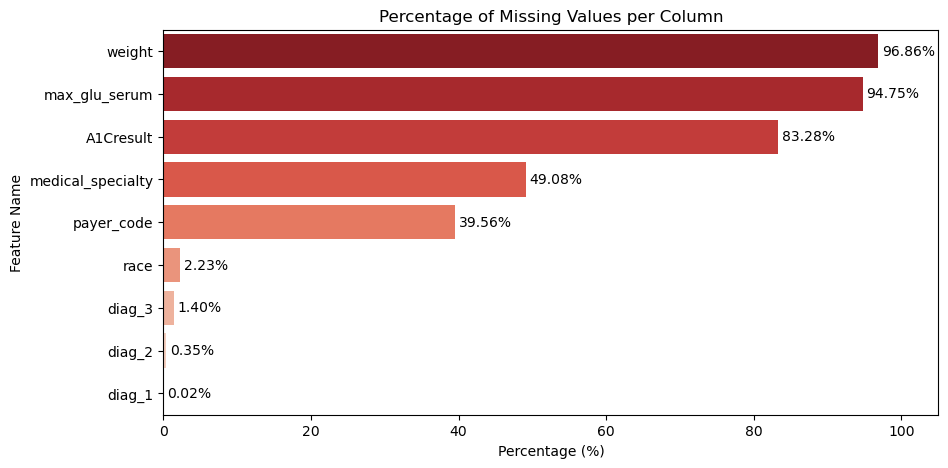

In [22]:

missing_summary = []

for col in df.columns:
    q_count = (df[col] == '?').sum() + df[col].isna().sum()
    if q_count > 0:
        pct = (q_count / len(df)) * 100
        missing_summary.append({'Column': col, 'Missing Count': q_count, 'Percentage (%)': pct})

df_missing = pd.DataFrame(missing_summary).sort_values(by='Percentage (%)', ascending=False)


plt.figure(figsize=(10, 5))
sns.barplot(data=df_missing, x='Percentage (%)', y='Column', palette='Reds_r')
plt.title('Percentage of Missing Values per Column')
plt.xlabel('Percentage (%)')
plt.ylabel('Feature Name')

for index, value in enumerate(df_missing['Percentage (%)']):
    plt.text(value + 0.5, index, f"{value:.2f}%", va='center')

plt.xlim(0, 105)
plt.show()

**Missing Values Insights:**
- `weight` has the highest missing rate (**96.86%**), followed by `medical_specialty` (**49.08%**) and `payer_code` (**39.56%**).
- `race`, `diag_1`, `diag_2`, and `diag_3` have minor missing rates (< 2.5%).
- `max_glu_serum` and `A1Cresult` are mostly `None` (untested).

## 2. Target Variable Analysis (`readmitted`)
Exploring the distribution of the target variable to check for class imbalance.

In [23]:
target_counts = df['readmitted'].value_counts()
target_pct = df['readmitted'].value_counts(normalize=True) * 100
target_counts.head()
target_pct.head()

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

C:\Users\User\AppData\Local\Temp\ipykernel_6700\1779905195.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax[0], palette="Set2")


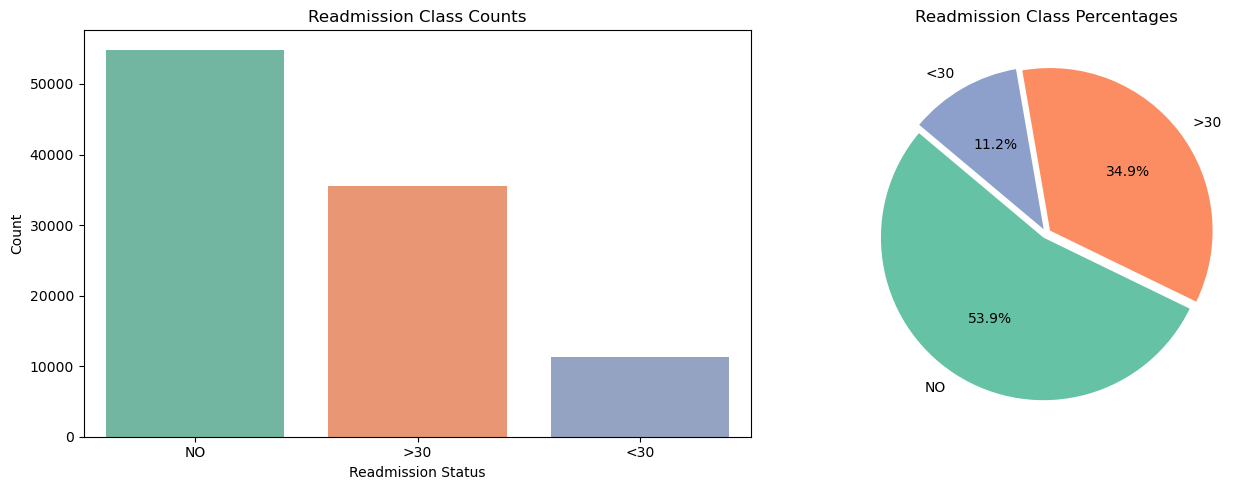

In [24]:
target_counts = df['readmitted'].value_counts()
target_pct = df['readmitted'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax[0], palette="Set2")
ax[0].set_title("Readmission Class Counts")
ax[0].set_xlabel("Readmission Status")
ax[0].set_ylabel("Count")


# Pie Chart
ax[1].pie(target_pct, labels=target_pct.index, autopct='%1.1f%%',
           startangle=140, colors=sns.color_palette("Set2"), explode=(0.03, 0.03, 0.03))
ax[1].set_title("Readmission Class Percentages")

plt.tight_layout()
plt.show()

**Target Variable Insights:**
- **NO (53.9%):** More than half of the patients were not readmitted.
- **>30 (34.9%):** Readmitted after 30 days.
- **<30 (11.2%):** Readmitted within 30 days (High-risk group).
- *Imbalance Note:* There is a clear class imbalance, especially for the `<30` category.

## 3. Patient Demographics vs. Readmission (`age`, `gender`, `race`)
Understanding how patient demographics relate to readmission rates.

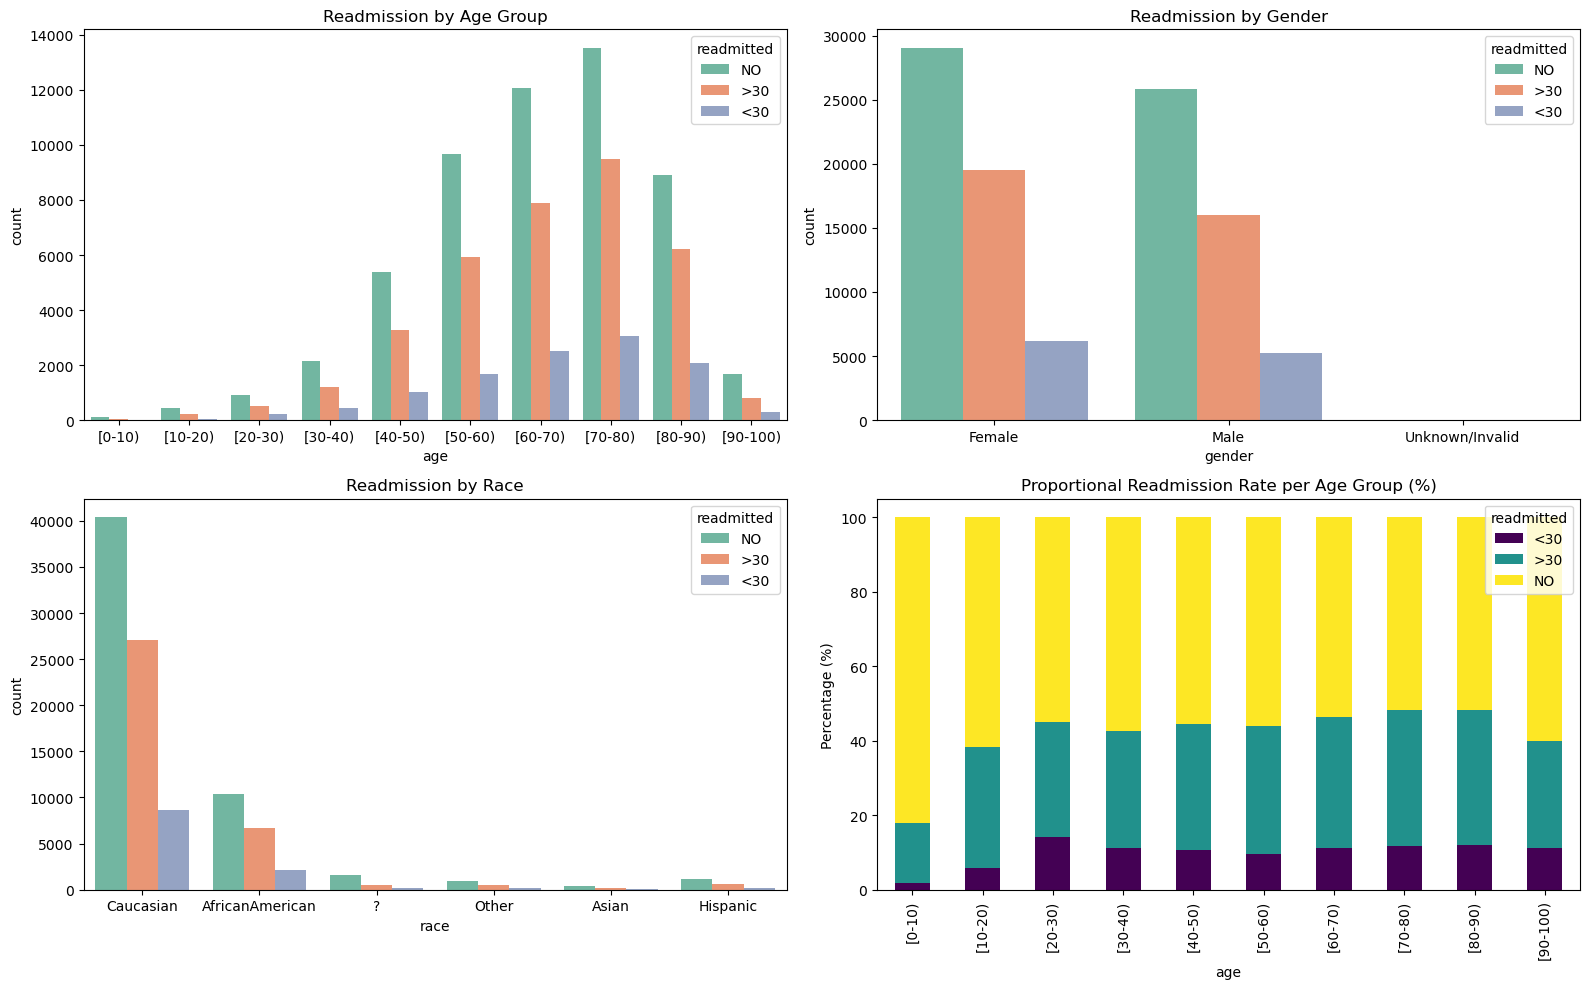

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Age Distribution
sns.countplot(data=df, x='age', hue='readmitted', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Readmission by Age Group')


# Gender Distribution
sns.countplot(data=df, x='gender', hue='readmitted', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Readmission by Gender')

# Race Distribution
sns.countplot(data=df, x='race', hue='readmitted', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Readmission by Race')


# Proportional Age Readmission Rate
age_readmit = pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100
age_readmit.plot(kind='bar', stacked=True, ax=axes[1,1], colormap='viridis')
axes[1,1].set_title('Proportional Readmission Rate per Age Group (%)')
axes[1,1].set_ylabel('Percentage (%)')



plt.tight_layout()
plt.show()

**Demographics Insights:**
- **Age:** Most patients belong to older age groups (`[60-70)`, `[70-80)`, `[80-90)`). Readmission rates (both `<30` and `>30`) increase progressively with age.
- **Gender:** Females represent slightly more cases than males, but readmission distribution is almost identical across genders.
- **Race:** Caucasian patients make up the majority of the dataset, followed by African American patients.

## 4. Numerical Features Distribution & Correlations
Analyzing numerical variables such as stay duration, lab procedures, and medication counts.

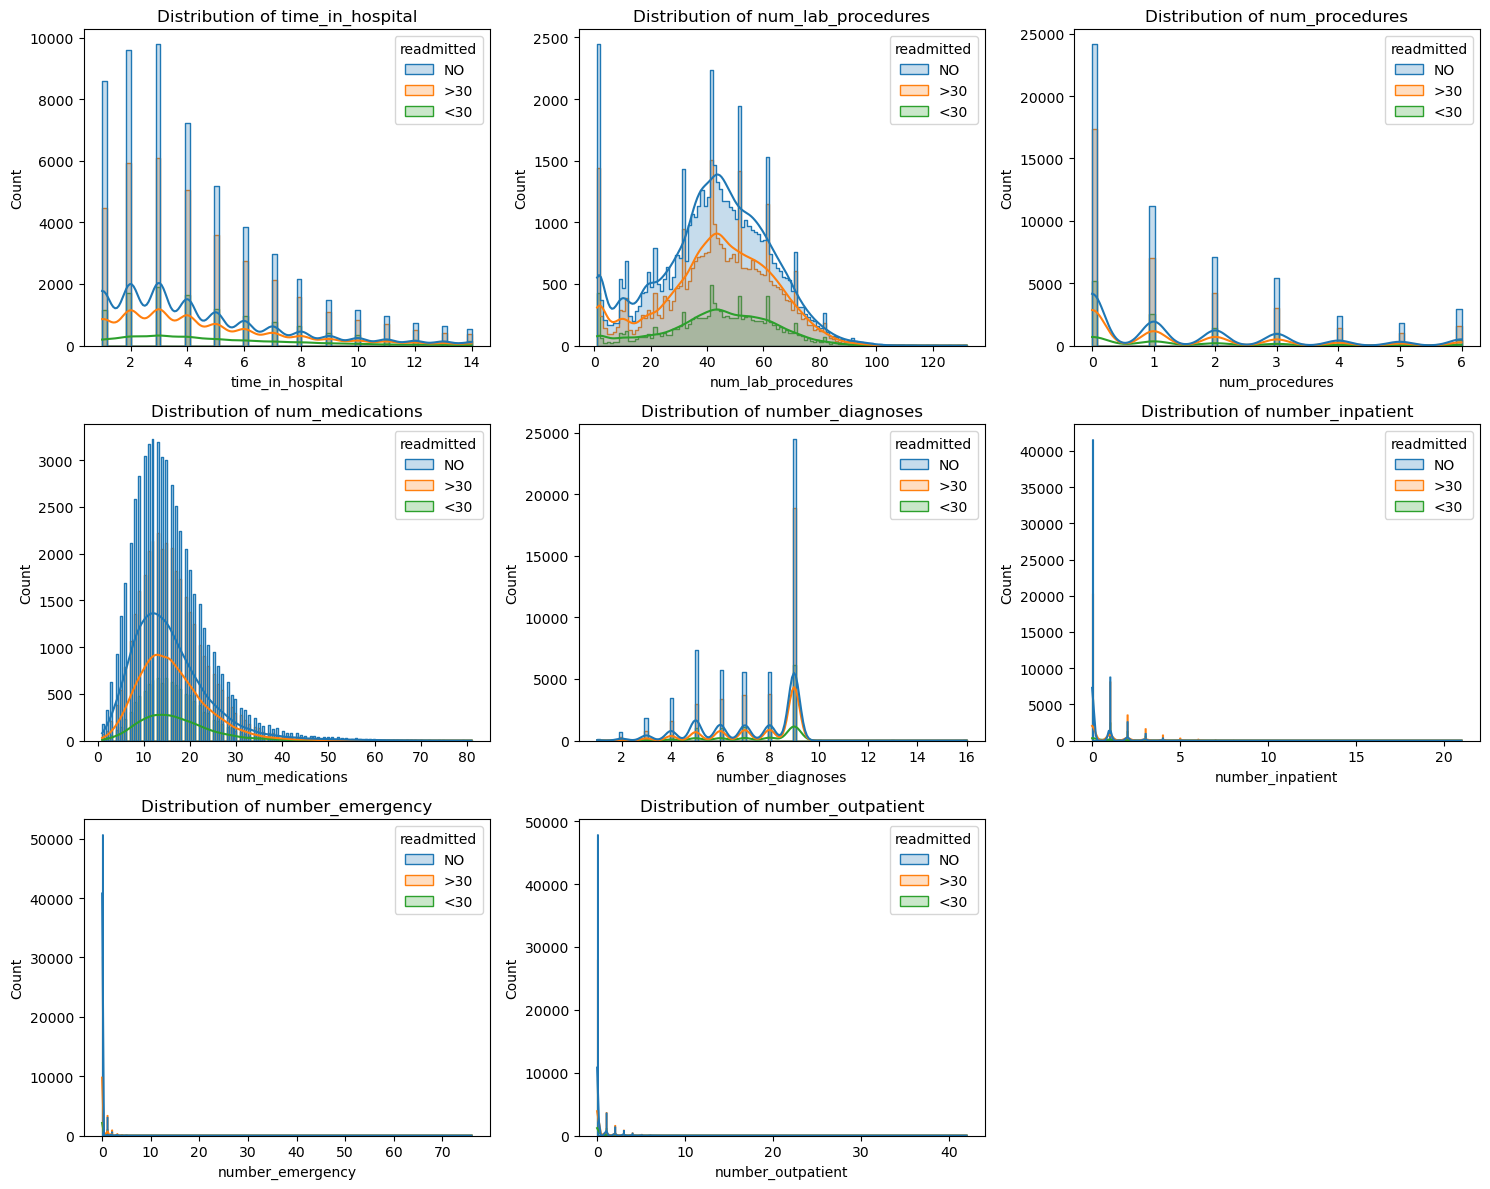

In [26]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'number_inpatient',
            'number_emergency', 'number_outpatient']

# Distribution Histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='readmitted', kde=True, ax=axes[i], element="step")
    axes[i].set_title(f'Distribution of {col}')

fig.delaxes(axes[8])
plt.tight_layout()
plt.show()

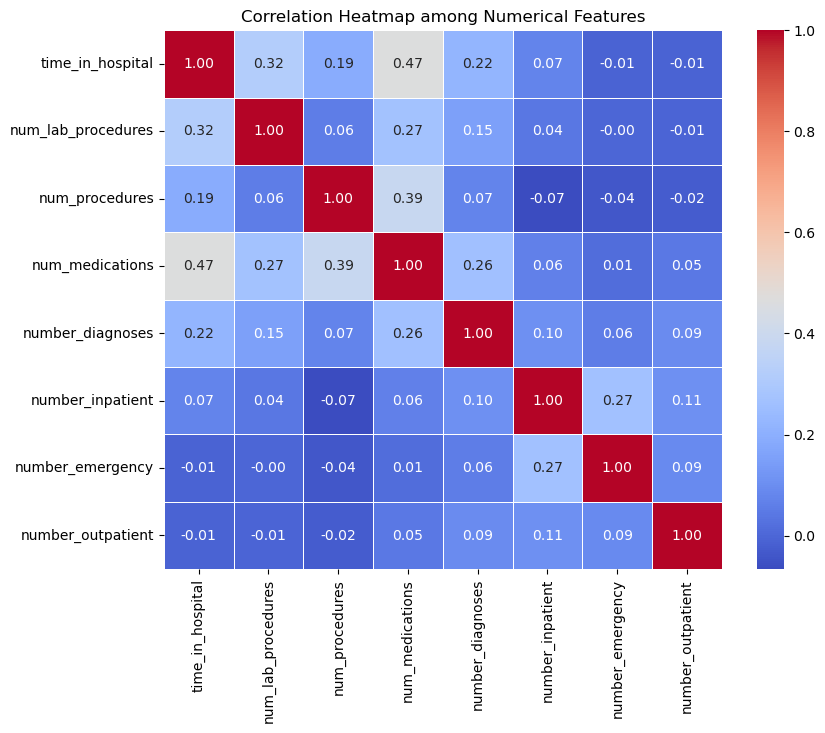

In [27]:
# Correlation Heatmap
plt.figure(figsize=(9, 7))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap among Numerical Features')
plt.show()

**Numerical Features Insights:**
- **Prior Hospital Visits (`number_inpatient`):** Patients with a higher number of prior inpatient visits show a much stronger likelihood of readmission.
- **Hospital Stay vs. Medications:** Moderate positive correlation ($r \approx 0.47$) between `time_in_hospital` and `num_medications`.
- **Skewness:** Features like `number_emergency`, `number_inpatient`, and `number_outpatient` are heavily right-skewed with high zero concentrations.

## 5. Patient Re-encounter Analysis
We check whether encounters represent unique individuals or multiple hospital admissions per patient.

Total Encounters: 101,766
Unique Patients: 71,518
Multiple Encounters Percentage: 29.72%


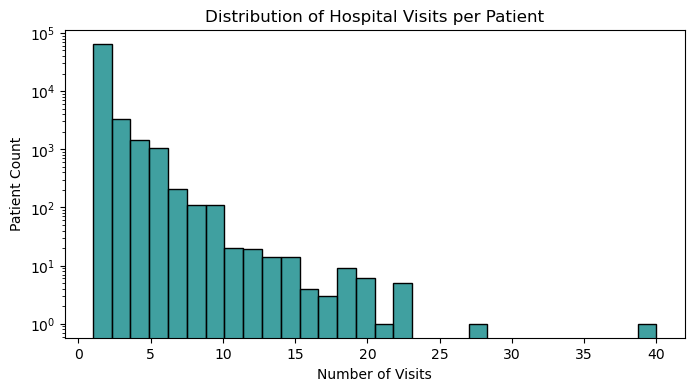

In [28]:
total_encounters = len(df)
unique_patients = df['patient_nbr'].nunique()

print(f"Total Encounters: {total_encounters:,}")
print(f"Unique Patients: {unique_patients:,}")
print(f"Multiple Encounters Percentage: {((total_encounters - unique_patients) / total_encounters) * 100:.2f}%")

encounters_per_patient = df['patient_nbr'].value_counts()

plt.figure(figsize=(8, 4))
sns.histplot(encounters_per_patient, bins=30, kde=False, color='teal')
plt.title('Distribution of Hospital Visits per Patient')
plt.xlabel('Number of Visits')
plt.ylabel('Patient Count')
plt.yscale('log') # Log scale because most patients have 1 visit
plt.show()

**Patient Encounter Insights:**
- The dataset contains **101,766 encounters** belonging to **71,518 unique patients**.
- Approximately **29.7% of entries** represent repeat admissions for existing patients.
- *Modeling implications:* We must decide during Preprocessing whether to keep all encounters or retain only the first visit per patient to prevent data leakage.

## 6. Admission Source & Discharge Disposition Analysis
Mapping numerical IDs using `IDS_mapping.csv` to understand how discharge destination affects readmission.

In [29]:
top_discharge = df['discharge_disposition_id'].value_counts().head(10)
top_discharge.head()

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
Name: count, dtype: int64

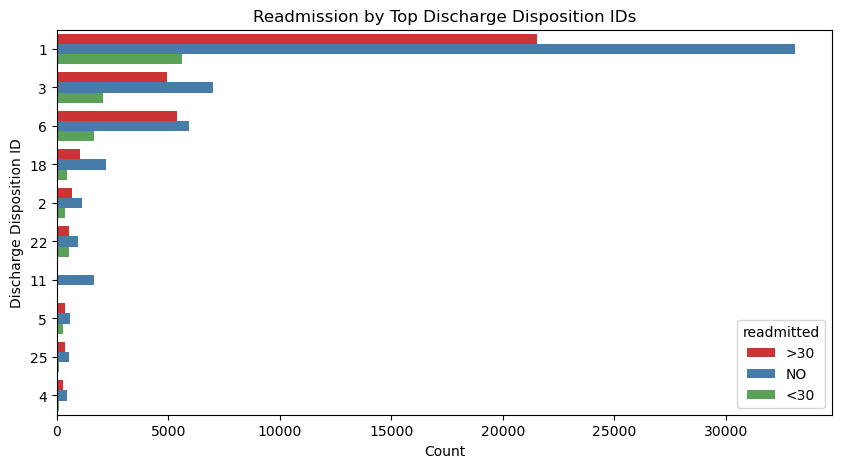

In [30]:
df_ids = pd.read_csv('data/IDS_mapping.csv')

top_discharge = df['discharge_disposition_id'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['discharge_disposition_id'].isin(top_discharge.index)],
              y='discharge_disposition_id', hue='readmitted', palette='Set1',
              order=top_discharge.index)
plt.title('Readmission by Top Discharge Disposition IDs')
plt.xlabel('Count')
plt.ylabel('Discharge Disposition ID')
plt.show()

**Discharge & Admission Insights:**
- ID `1` (Discharged to Home) accounts for the vast majority of cases.
- IDs like `11`, `19`, `20` represent patients who expired (died); these patients cannot be readmitted, which is a critical finding for data cleaning!

## 7. Diabetes Medications & Treatment Changes
Analyzing the relation between medication adjustments (`change`), active prescriptions (`diabetesMed`), and insulin level changes (`insulin`).

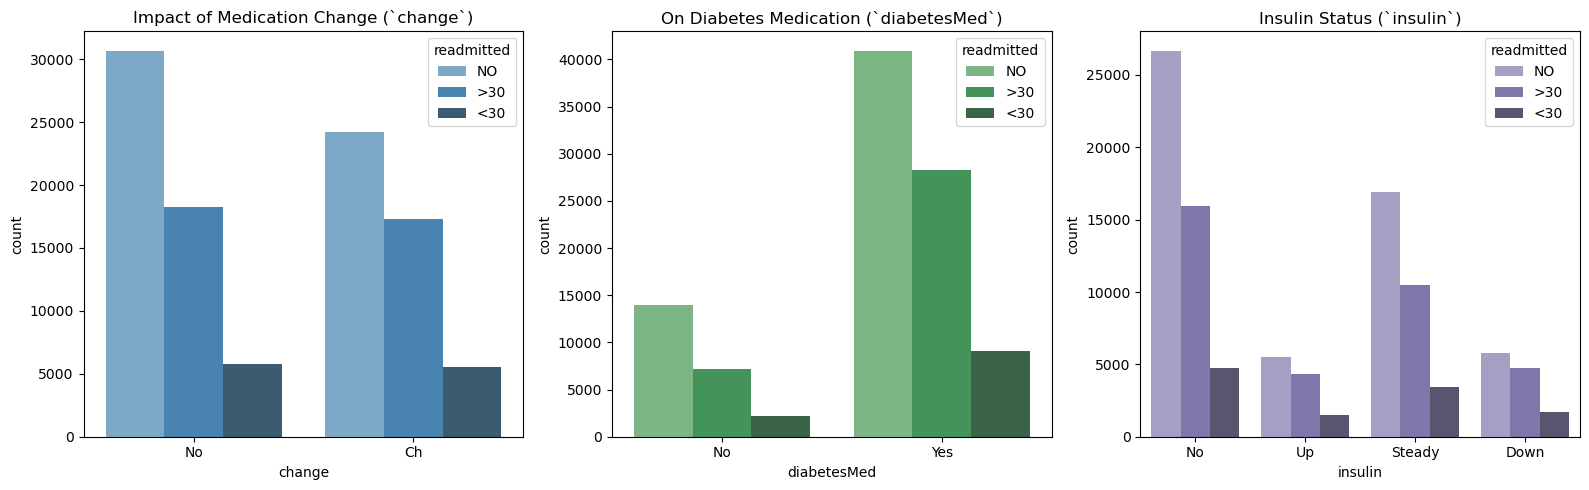

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Medication Change vs Readmitted
sns.countplot(data=df, x='change', hue='readmitted', ax=axes[0], palette='Blues_d')
axes[0].set_title('Impact of Medication Change (`change`)')

# Diabetes Med Prescribed vs Readmitted
sns.countplot(data=df, x='diabetesMed', hue='readmitted', ax=axes[1], palette='Greens_d')
axes[1].set_title('On Diabetes Medication (`diabetesMed`)')

# Insulin Status vs Readmitted
sns.countplot(data=df, x='insulin', hue='readmitted', ax=axes[2], palette='Purples_d')
axes[2].set_title('Insulin Status (`insulin`)')

plt.tight_layout()
plt.show()

**Medication Insights:**
- Patients who had a **change in medication dosage (`Ch`)** show higher readmission rates compared to those with no change (`No`).
- Patients on **Insulin** (especially `Up` or `Down` adjustments) show a noticeable increase in early readmissions (<30 days), indicating unstable blood glucose levels.

# Comprehensive Summary & Insights for Preprocessing Strategy

---

### 1. High Missing Values & Column Filtering
- **`weight`:** Missing in **96.86%** of rows. It contains almost no useful variance and should be dropped.
- **`medical_specialty` (~49.1% missing) & `payer_code` (~39.6% missing):** High percentage of missingness (`?`). Needs explicit missing category imputation (e.g., `'Missing'` or `'Unknown'`) rather than row deletion.
- **`race` (~2.2% missing):** Can be imputed using mode or categorized as `'Unknown'`.
- **`max_glu_serum` & `A1Cresult`:** Over 80% are recorded as `'None'` (untested). Treat `'None'` as a valid indicator category rather than missing data.

---

### 2. Patient Multi-Encounters & Data Leakage Avoidance
- The dataset contains **101,766 encounters** representing **71,518 unique patients**.
- ~29.7% of records are repeat visits by existing patients (`patient_nbr`).
- **Action for Preprocessing:** To prevent data leakage and correlation bias, consider dropping duplicate patients by keeping only their **first encounter** (`df.drop_duplicates(subset=['patient_nbr'], keep='first')`).

---

### 3. Patient Mortality / Non-Readmittable Discharges
- Specific codes in `discharge_disposition_id` represent patients who expired (died) in the hospital or were discharged to hospice (e.g., **IDs 11, 19, 20, 21**).
- **Action for Preprocessing:** These patients **cannot biologically be readmitted**. They should be filtered out from the dataset before training any predictive model to avoid learning invalid signals.

---

### 4. Target Variable Encoding & Class Imbalance
- **Current Classes:** `NO` (53.9%), `>30` (34.9%), `<30` (11.2%).
- **Modeling Choice:** - If framing as **Binary Classification** (High Risk vs Low Risk), map `<30` $\rightarrow 1$ and `(>30, NO)` $\rightarrow 0$.
- **Class Imbalance:** Target class `<30` accounts for only ~11.2%. Require handling methods such as **SMOTE**, **Class Weights**, or appropriate evaluation metrics (PR-AUC, Recall, F1-score instead of raw Accuracy).

---

### 5. High Predictive Numerical & Categorical Features Identified
- **`number_inpatient`:** Showed the highest individual impact on early readmissions (<30 days). Prior hospitalizations are strong indicators of future risk.
- **`age`:** Older age brackets (`[60-70)`, `[70-80)`, `[80-90)`) exhibit progressively higher readmission rates. Can be converted to ordinal integer values (e.g., midpoints like 65, 75, 85).
- **Medication Adjustments (`change` & `insulin`):** Patients with dosage changes (`Ch`) or active insulin regimen adjustments (`Up` / `Down`) have a higher tendency for readmission, reflecting disease instability.

---

###  Preprocessing Checklist for the Next Phase:
1. Replace all `'?'` string values with standard `NaN` or appropriate categories.
2. Filter out expired/hospice patients based on `discharge_disposition_id`.
3. Deduplicate multiple patient encounters (`patient_nbr`).
4. Drop non-informative / extremely sparse features (`weight`, `encounter_id`).
5. Map diagnostic codes (`diag_1`, `diag_2`, `diag_3`) into broader clinical categories (ICD-9 grouping: Circulatory, Respiratory, Diabetes, etc.).
6. Scale skewed numerical features (`number_inpatient`, `number_emergency`, `time_in_hospital`).
7. Encode categorical variables using Target Encoding or One-Hot Encoding.


**Removing encounters** : where the patient expired during the hospital stay (IDs 11, 19, 20, 21),
as these cases cannot logically be readmitted and would introduce invalid signals into the model.

In [32]:
# Removing Deceased Patients (discharge_disposition_id)
expired_ids = [11,13,14, 19, 20, 21]

print(f"Rows before removal: {df.shape[0]}")

df = df[~df['discharge_disposition_id'].isin(expired_ids)]

print(f"Rows after removal: {df.shape[0]}")

Rows before removal: 101766
Rows after removal: 99343


# Handling Invalid / Placeholder Values (Not Available, NULL, Not Mapped)
Converting hidden missing values in `admission_type_id`, `admission_source_id`, and `discharge_disposition_id`
(IDs representing "Not Available", "NULL", or "Not Mapped") into proper `NaN`, so they are treated as true
missing data instead of meaningful categories.

In [33]:
# replace all '?' with nan
df = df.replace('?', np.nan)

In [34]:
#Handling Invalid / Placeholder Values (Not Available, NULL, Not Mapped)

invalid_admission_type = [5, 6, 8]          # Not Available, NULL, Not Mapped
invalid_admission_source = [9, 15 , 17 , 20 , 21]  # Not Available, NULL, Not Mapped , Unknown/Invalid
invalid_discharge = [18, 25 , 26]                # NULL, Not Mapped ,Unknown/Invalid

df['admission_type_id'] = df['admission_type_id'].replace(invalid_admission_type, np.nan)
df['admission_source_id'] = df['admission_source_id'].replace(invalid_admission_source, np.nan)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(invalid_discharge, np.nan)

print(df.isna().sum().sort_values(ascending=False).head(15))

weight                      96218
max_glu_serum               94191
A1Cresult                   82509
medical_specialty           48616
payer_code                  39398
admission_type_id           10144
admission_source_id          6854
discharge_disposition_id     4680
race                         2234
diag_3                       1419
diag_2                        356
diag_1                         20
acarbose                        0
miglitol                        0
troglitazone                    0
dtype: int64


📊 Missing Values After Cleaning

The main features with missing values were:

- weight → 96,218
- max_glu_serum → 94,191
- A1Cresult → 82,509
- medical_specialty → 48,616
- payer_code → 39,398
- admission_type_id → 10,144
- admission_source_id → 6,854
- discharge_disposition_id → 4,680

# Handling Invalid Gender Values


In [35]:
# Handling Invalid Gender Values
print(f"Unknown/Invalid count: {(df['gender'] == 'Unknown/Invalid').sum()}")

df['gender'] = df['gender'].replace('Unknown/Invalid', np.nan)

print(df['gender'].unique())
print(df['gender'].isna().sum())

Unknown/Invalid count: 3
['Female' 'Male' nan]
3


In [36]:
X = df.drop(columns=['readmitted'])
y = df['readmitted']
groups=df['patient_nbr']

In [37]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [38]:
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (79541, 49)
Test shape: (19802, 49)


In [39]:
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
readmitted
NO     0.528419
>30    0.357199
<30    0.114381
Name: proportion, dtype: float64

Test distribution:
readmitted
NO     0.530047
>30    0.358045
<30    0.111908
Name: proportion, dtype: float64


# Spliting the data


Why GroupShuffleSplit instead of standard train_test_split:

29.7% of encounters are repeat visits from the same patient (patient_nbr repeats). A normal train_test_split splits row-by-row, so the same patient's visits could end up split across both train and test — causing data leakage (model partially "sees" that patient during training, inflating performance).

GroupShuffleSplit splits at the patient level instead, keeping all of a patient's encounters together in either train or test — never both. This ensures the model is always evaluated on truly unseen patients.

# Handling nan values


In [40]:
X_train = X_train.drop(columns=['weight'])
X_test = X_test.drop(columns=['weight'])

In [41]:
cols_to_fill = ['medical_specialty', 'payer_code', 'race']
for col in cols_to_fill:
    X_train[col] = X_train[col].fillna('unkown')
    X_test[col] = X_test[col].fillna('unkown')



In [42]:
X_train['max_glu_serum']=X_train['max_glu_serum'].fillna('Not Tested')
X_test['max_glu_serum']=X_test['max_glu_serum'].fillna('Not Tested')

In [43]:
X_train['A1Cresult']=X_train['A1Cresult'].fillna('Not Tested')
X_test['A1Cresult']=X_test['A1Cresult'].fillna('Not Tested')

In [44]:
id_cols = ['admission_type_id', 'admission_source_id', 'discharge_disposition_id']
for col in id_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

In [45]:
mode_gender = X_train['gender'].mode()[0]
X_train['gender'] = X_train['gender'].fillna(mode_gender)
X_test['gender'] = X_test['gender'].fillna(mode_gender)

In [46]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

In [47]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitaz

# Remove columns with zero variance

In [48]:
X_train.drop(columns=['examide','citoglipton'],inplace=True)
X_test.drop(columns=['examide','citoglipton'],inplace=True)

# Feature Transformation

In [ ]:
def categorize_diagnosis(code):

    code = str(code)
    if code.startswith('V'):
        return 'Supplemental'
    if code.startswith('E'):
        return 'External'
    try:
        code_num = float(code)
    except:
        if code == "Unknown" :
            return "Unknown"
        return 'Other'

    if 250 <= code_num < 251:
        return 'Diabetes'
    elif 390 <= code_num <= 459:
        return 'Circulatory'
    elif 460 <= code_num <= 519:
        return 'Respiratory'
    elif 520 <= code_num <= 579:
        return 'Digestive'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif 580 <= code_num <= 629:
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    else:
        return 'Others'

for col in ['diag_1', 'diag_2', 'diag_3']:
    X_train[f'{col}_category'] = X_train[col].apply(categorize_diagnosis)
    X_test[f'{col}_category'] = X_test[col].apply(categorize_diagnosis)

X_train[['diag_1_category', 'diag_2_category', 'diag_3_category']].apply(lambda x: x.value_counts())

,diag_1_category,diag_2_category,diag_3_category
Circulatory,23660,24494,23459
Diabetes,6930,10189,13574
Digestive,7286,3108,2823
External,1,567,995
Genitourinary,3963,6185,4849
Injury,5475,1899,1497
Musculoskeletal,3972,1404,1501
Neoplasms,2516,1864,1310
Others,16441,20202,20130
Respiratory,7992,7876,5167


In [ ]:
numerical_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

skewness = X_train[numerical_cols].skew()

print(skewness.sort_values(ascending=False))

number_emergency      24.938834
number_outpatient      8.233772
number_inpatient       3.510391
num_medications        1.345194
num_procedures         1.322304
time_in_hospital       1.141764
num_lab_procedures    -0.246909
number_diagnoses      -0.868332
dtype: float64


In [ ]:
import numpy as np

skewed_features = [
    'number_emergency',
    'number_outpatient',
    'number_inpatient',
    'num_medications',
    'num_procedures',
    'time_in_hospital'
]

for col in skewed_features:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

In [ ]:
numerical_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

skewness = X_train[numerical_cols].skew()

print(skewness.sort_values(ascending=False))

number_emergency      3.641946
number_outpatient     2.718311
number_inpatient      1.439108
num_procedures        0.526532
time_in_hospital      0.106902
num_lab_procedures   -0.246909
num_medications      -0.488483
number_diagnoses     -0.868332
dtype: float64


In [ ]:
# numeric_features = [
#     'time_in_hospital',
#     'num_lab_procedures',
#     'num_procedures',
#     'num_medications',
#     'number_outpatient',
#     'number_emergency',
#     'number_inpatient',
#     'number_diagnoses'
# ]

# for col in numeric_features:
#     Q1 = X_train[col].quantile(0.25)
#     Q3 = X_train[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     outliers = X_train[
#         (X_train[col] < lower_bound) |
#         (X_train[col] > upper_bound)
#     ]

#     print(
#         f"{col}: "
#         f"{len(outliers)} outliers "
#         f"({len(outliers)/len(X_train)*100:.2f}%)"
#     )

## Feature Engineering experiments:
### [num_meds_up , num_meds_down , num_med_changes , num_meds_prescribed]
## Results:
### Before Feature Engineering: 63.14% Accuracy
### After Feature Engineering: 62.72% Accuracy
### Keeping original medication features + new features: 62.94%
## Conclusion: Feature Engineering did not improve the Accuracy, so the original medication columns were kept.


# # 1. NUMERICAL FEATURES → STANDARD SCALING


In [54]:
numerical_columns = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

numerical_scaler = StandardScaler()

X_train[numerical_columns] = numerical_scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = numerical_scaler.transform(
    X_test[numerical_columns]
)


# 2. BINARY CATEGORICAL → 0 / 1

In [55]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Gender
X_train['gender'] = X_train['gender'].map({
    'Female': 0,
    'Male': 1
})

X_test['gender'] = X_test['gender'].map({
    'Female': 0,
    'Male': 1
})


# Change
X_train['change'] = X_train['change'].map({
    'No': 0,
    'Ch': 1
})

X_test['change'] = X_test['change'].map({
    'No': 0,
    'Ch': 1
})


# Diabetes Medication
X_train['diabetesMed'] = X_train['diabetesMed'].map({
    'No': 0,
    'Yes': 1
})

X_test['diabetesMed'] = X_test['diabetesMed'].map({
    'No': 0,
    'Yes': 1
})


# 3. AGE → ORDINAL ENCODING

In [56]:
age_mapping = {
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9
}

X_train['age'] = X_train['age'].map(age_mapping)
X_test['age'] = X_test['age'].map(age_mapping)


# Scale Age after ordinal encoding
age_scaler = StandardScaler()

X_train[['age']] = age_scaler.fit_transform(
    X_train[['age']]
)

X_test[['age']] = age_scaler.transform(
    X_test[['age']]
)


# 4. max_glu_serum → ORDINAL ENCODING

In [57]:
print(X_train['max_glu_serum'].value_counts(dropna=False))
print(X_train['A1Cresult'].value_counts(dropna=False))

max_glu_serum
Not Tested    75433
Norm           2059
>200           1144
>300            905
Name: count, dtype: int64
A1Cresult
Not Tested    66058
>8             6544
Norm           3932
>7             3007
Name: count, dtype: int64


In [58]:
glu_mapping = {
    'Not Tested': 0,
    'Norm': 1,
    '>200': 2,
    '>300': 3
}

X_train['max_glu_serum'] = X_train['max_glu_serum'].map(glu_mapping)
X_test['max_glu_serum'] = X_test['max_glu_serum'].map(glu_mapping)


# Scale max_glu_serum
glu_scaler = StandardScaler()

X_train[['max_glu_serum']] = glu_scaler.fit_transform(
    X_train[['max_glu_serum']]
)

X_test[['max_glu_serum']] = glu_scaler.transform(
    X_test[['max_glu_serum']]
)


# 5. A1Cresult → ORDINAL ENCODING

In [59]:
a1c_mapping = {
    'Not Tested': 0,
    'Norm': 1,
    '>7': 2,
    '>8': 3
}

X_train['A1Cresult'] = X_train['A1Cresult'].map(a1c_mapping)
X_test['A1Cresult'] = X_test['A1Cresult'].map(a1c_mapping)


# Scale A1Cresult
a1c_scaler = StandardScaler()

X_train[['A1Cresult']] = a1c_scaler.fit_transform(
    X_train[['A1Cresult']]
)

X_test[['A1Cresult']] = a1c_scaler.transform(
    X_test[['A1Cresult']]
)

# 6. DIAGNOSIS CATEGORIES → ONE-HOT ENCODING

In [60]:
diagnosis_columns = [
    'diag_1_category',
    'diag_2_category',
    'diag_3_category'
]

diagnosis_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_diag = diagnosis_encoder.fit_transform(
    X_train[diagnosis_columns]
)

X_test_diag = diagnosis_encoder.transform(
    X_test[diagnosis_columns]
)


X_train_diag = pd.DataFrame(
    X_train_diag,
    index=X_train.index,
    columns=diagnosis_encoder.get_feature_names_out(
        diagnosis_columns
    )
)

X_test_diag = pd.DataFrame(
    X_test_diag,
    index=X_test.index,
    columns=diagnosis_encoder.get_feature_names_out(
        diagnosis_columns
    )
)


# 7. NOMINAL CATEGORICAL
# race + payer_code + medical_specialty→ ONE-HOT ENCODING

In [61]:
nominal_columns = [
    'race',
    'payer_code',
    'medical_specialty'
]

categorical_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = categorical_encoder.fit_transform(
    X_train[nominal_columns]
)

X_test_cat = categorical_encoder.transform(
    X_test[nominal_columns]
)


X_train_cat = pd.DataFrame(
    X_train_cat,
    index=X_train.index,
    columns=categorical_encoder.get_feature_names_out(
        nominal_columns
    )
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    index=X_test.index,
    columns=categorical_encoder.get_feature_names_out(
        nominal_columns
    )
)


# 8. ADMISSION / DISCHARGE IDs → ONE-HOT ENCODING

In [62]:
id_columns = [
    'admission_type_id',
    'admission_source_id',
    'discharge_disposition_id'
]

id_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_id = id_encoder.fit_transform(
    X_train[id_columns]
)

X_test_id = id_encoder.transform(
    X_test[id_columns]
)


X_train_id = pd.DataFrame(
    X_train_id,
    index=X_train.index,
    columns=id_encoder.get_feature_names_out(
        id_columns
    )
)

X_test_id = pd.DataFrame(
    X_test_id,
    index=X_test.index,
    columns=id_encoder.get_feature_names_out(
        id_columns
    )
)

# 9. MEDICATIONS → ONE-HOT ENCODING

In [63]:
medication_columns = [
    'metformin',
    'repaglinide',
    'nateglinide',
    'chlorpropamide',
    'glimepiride',
    'glipizide',
    'glyburide',
    'tolbutamide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'miglitol',
    'troglitazone',
    'tolazamide',
    'insulin',
    'glyburide-metformin',
    'glipizide-metformin',
    'metformin-rosiglitazone',
    'metformin-pioglitazone',
    'acetohexamide',
    'glimepiride-pioglitazone' # Removed 'examide' and 'citoglipton'
]

medication_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_med = medication_encoder.fit_transform(
X_train[medication_columns]
)

X_test_med = medication_encoder.transform(
    X_test[medication_columns]
)


X_train_med = pd.DataFrame(
    X_train_med,
    index=X_train.index,
    columns=medication_encoder.get_feature_names_out(
        medication_columns
    )
)

X_test_med = pd.DataFrame(
    X_test_med,
    index=X_test.index,
    columns=medication_encoder.get_feature_names_out(
        medication_columns
    )
)


# 10. DROP ORIGINAL CATEGORICAL COLUMNS

In [64]:
columns_to_drop = (
    diagnosis_columns
    + nominal_columns
    + id_columns
    + medication_columns
    + ['diag_1', 'diag_2', 'diag_3']
)

X_train_base = X_train.drop(
    columns=columns_to_drop
)

X_test_base = X_test.drop(
    columns=columns_to_drop
)

# 11. COMBINE EVERYTHING

In [65]:
X_train_encoded = pd.concat(
    [
        X_train_base,
        X_train_diag,
        X_train_cat,
        X_train_id,
        X_train_med
    ],
    axis=1
)

X_test_encoded = pd.concat(
    [
        X_test_base,
        X_test_diag,
        X_test_cat,
        X_test_id,
        X_test_med
    ],
    axis=1
)

# 12. RESET INDEX

In [66]:
X_train_encoded = X_train_encoded.reset_index(drop=True)
X_test_encoded = X_test_encoded.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


# 13. FINAL CHECK

In [67]:
print("X_train shape:", X_train_encoded.shape)
print("X_test shape:", X_test_encoded.shape)

print("\nMissing values:")
print("X_train:", X_train_encoded.isnull().sum().sum())
print("X_test:", X_test_encoded.isnull().sum().sum())

print("\nData types:")
print(X_train_encoded.dtypes.value_counts())


X_train shape: (79541, 254)
X_test shape: (19802, 254)

Missing values:
X_train: 0
X_test: 0

Data types:
float64    249
int64        5
Name: count, dtype: int64


In [68]:
print("Number of features:", X_train_encoded.shape[1])

Number of features: 254


In [69]:
print(y_train.value_counts())

print("\nPercentage:")
print(y_train.value_counts(normalize=True) * 100)

readmitted
NO     42031
>30    28412
<30     9098
Name: count, dtype: int64

Percentage:
readmitted
NO     52.841931
>30    35.719943
<30    11.438126
Name: proportion, dtype: float64


# Feature Transformation

In [70]:
X_train_encoded.tail(30)

,encounter_id,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,glyburide-metformin_Up,glipizide-metformin_No,glipizide-metformin_Steady,metformin-rosiglitazone_No,metformin-rosiglitazone_Steady,metformin-pioglitazone_No,metformin-pioglitazone_Steady,acetohexamide_No,acetohexamide_Steady,glimepiride-pioglitazone_No
79511,443729846,174755165,0,1.209882,0.761605,0.412552,-0.946944,0.347907,-0.402009,-0.324225,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
79512,443739044,106595208,1,0.581112,0.761605,0.157133,1.796064,-0.024884,-0.402009,-0.324225,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
79513,443739152,90751788,0,-0.047659,1.234350,0.565804,0.114196,0.663097,1.210631,-0.324225,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
79514,443775086,125764160,0,-1.305201,0.128669,0.361468,1.516948,1.099789,-0.402009,-0.324225,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
79515,443775482,95780439,1,0.581112,-1.594958,-0.302622,-0.946944,-0.659054,-0.402009,-0.324225,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
79516,443775740,30656952,1,0.581112,-1.594958,-0.558042,2.032054,-0.024884,2.153964,-0.324225,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
79517,443778398,134647673,1,-1.305201,-1.594958,-2.141642,1.796064,-1.069363,-0.402009,-0.324225,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
79518,443787128,58160520,1,1.838653,0.128669,-1.119964,0.114196,-1.069363,-0.402009,-0.324225,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
79519,443787512,52419276,1,0.581112,0.128669,0.003881,-0.946944,-0.659054,-0.402009,-0.324225,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
79520,443797076,183766055,1,-0.676430,-0.291084,0.719055,-0.946944,-1.310192,-0.402009,1.872533,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0


In [71]:
X_train_encoded = X_train_encoded.drop(
    columns=['encounter_id', 'patient_nbr'],
    errors='ignore'
)

X_test_encoded = X_test_encoded.drop(
    columns=['encounter_id', 'patient_nbr'],
    errors='ignore'
)

In [72]:
y_train_binary = y_train.map({
    'NO': 0,
    '>30': 1,
    '<30': 1
})

y_test_binary = y_test.map({
    'NO': 0,
    '>30': 1,
    '<30': 1
})

# Modeling

In [73]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Handle NaNs in y_train_binary and align X_train_encoded
nan_mask_train = y_train_binary.isna()
X_train_encoded_cleaned = X_train_encoded[~nan_mask_train]
y_train_binary_cleaned = y_train_binary[~nan_mask_train]

# No NaNs in y_test_binary, so no cleaning needed for test set
X_test_encoded_cleaned = X_test_encoded
y_test_binary_cleaned = y_test_binary

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train_binary_cleaned)
y_test_encoded = label_encoder.transform(y_test_binary_cleaned)

print("Classes:", label_encoder.classes_)

# ==========================================
# 2. Random Forest - Grid Search
# ==========================================
# IMPORTANT:
# The SMOTETomek step below is kept unchanged.
# Random Forest is tuned using the balanced training data.

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Running Random Forest GridSearchCV...")
rf_grid.fit(X_train_encoded_cleaned, y_train_encoded)

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)
print(f"Best CV Accuracy: {rf_grid.best_score_:.2%}")

y_pred_rf = rf_grid.predict(X_test_encoded_cleaned)

print(f"\nRandom Forest GridSearch Test Accuracy: "
      f"{accuracy_score(y_test_encoded, y_pred_rf):.2%}")

print("\nRandom Forest Classification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_rf,
    target_names=[str(c) for c in label_encoder.classes_]
))


Classes: [0 1]
Running Random Forest GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
16 fits failed out of a total of 48.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\Lib\site-packages\joblib\_utils.py", line 72, in __call__
    return self.func(**kwargs)
           ~~~~~~~~~^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\paral


Best Random Forest Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy: 62.01%

Random Forest GridSearch Test Accuracy: 63.96%

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.74      0.68     10496
           1       0.64      0.53      0.58      9306

    accuracy                           0.64     19802
   macro avg       0.64      0.63      0.63     19802
weighted avg       0.64      0.64      0.64     19802



In [74]:

from imblearn.combine import SMOTETomek
import numpy as np

smote_tomek = SMOTETomek(
    random_state=42
)

# Impute remaining NaNs in X_train_encoded_cleaned with the mean of each column
X_train_encoded_imputed = X_train_encoded_cleaned.fillna(X_train_encoded_cleaned.mean())

X_train_balanced, y_train_balanced = smote_tomek.fit_resample(
    X_train_encoded_imputed, # Use the imputed DataFrame derived from the cleaned X
    y_train_encoded
)

In [75]:
# ==========================================
# 3. Random Forest + SMOTETomek
# ==========================================
# SMOTETomek is intentionally NOT modified.

rf_smote = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_rf_smote = rf_smote.predict(X_test_encoded)

print(f"Random Forest + SMOTETomek Accuracy: "
      f"{accuracy_score(y_test_encoded, y_pred_rf_smote):.2%}")

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_rf_smote,
    target_names=[str(c) for c in label_encoder.classes_]
))


Random Forest + SMOTETomek Accuracy: 63.26%

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.71      0.67     10496
           1       0.62      0.55      0.58      9306

    accuracy                           0.63     19802
   macro avg       0.63      0.63      0.63     19802
weighted avg       0.63      0.63      0.63     19802



In [76]:
# ==========================================
# 4. Random Forest - GridSearch AFTER SMOTETomek
# ==========================================
# This is the tuned Random Forest requested.
# It uses exactly the same X_train_balanced / y_train_balanced
# produced by the existing SMOTETomek cell.

rf_tuned = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_tuned_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_tuned_search = GridSearchCV(
    rf_tuned,
    rf_tuned_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Running tuned Random Forest GridSearchCV...")
rf_tuned_search.fit(
    X_train_balanced,
    y_train_balanced
)

print("\nBest Tuned Random Forest Parameters:")
print(rf_tuned_search.best_params_)
print(f"Best CV Accuracy: {rf_tuned_search.best_score_:.2%}")

y_pred_rf_tuned = rf_tuned_search.predict(X_test_encoded)

rf_tuned_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_rf_tuned
)

print(f"\nTuned Random Forest Test Accuracy: {rf_tuned_accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_rf_tuned,
    target_names=[str(c) for c in label_encoder.classes_]
))


Running tuned Random Forest GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Tuned Random Forest Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV Accuracy: 63.39%

Tuned Random Forest Test Accuracy: 63.66%

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.70      0.67     10496
           1       0.63      0.56      0.59      9306

    accuracy                           0.64     19802
   macro avg       0.64      0.63      0.63     19802
weighted avg       0.64      0.64      0.63     19802



In [78]:
# ==========================================
# 5. XGBoost + GridSearchCV
# ==========================================
# Uses the SAME balanced data created by the existing SMOTETomek step.

from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=2
)

xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=2,
    verbose=1
)

print("Running XGBoost GridSearchCV...")
xgb_grid.fit(
    X_train_balanced,
    y_train_balanced
)

print("\nBest XGBoost Parameters:")
print(xgb_grid.best_params_)
print(f"Best CV Accuracy: {xgb_grid.best_score_:.2%}")

y_pred_xgb = xgb_grid.predict(X_test_encoded)

xgb_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_xgb
)

print(f"\nXGBoost Test Accuracy: {xgb_accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_xgb,
    target_names=[str(c) for c in label_encoder.classes_]
))


Running XGBoost GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best XGBoost Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV Accuracy: 60.24%

XGBoost Test Accuracy: 63.38%

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.68     10496
           1       0.63      0.53      0.58      9306

    accuracy                           0.63     19802
   macro avg       0.63      0.63      0.63     19802
weighted avg       0.63      0.63      0.63     19802



In [81]:
# ==========================================
# 6. KNN + GridSearchCV
# ==========================================
# KNN is sensitive to feature scale, so a StandardScaler is used
# INSIDE the Pipeline to avoid data leakage during cross-validation.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_jobs=-1))
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=2,
    verbose=1
)

print("Running KNN GridSearchCV...")
knn_grid.fit(
    X_train_balanced,
    y_train_balanced
)

print("\nBest KNN Parameters:")
print(knn_grid.best_params_)
print(f"Best CV Accuracy: {knn_grid.best_score_:.2%}")

y_pred_knn = knn_grid.predict(X_test_encoded)

knn_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_knn
)

print(f"\nKNN Test Accuracy: {knn_accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_knn,
    target_names=[str(c) for c in label_encoder.classes_]
))


Running KNN GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best KNN Parameters:
{'knn__n_neighbors': 7, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV Accuracy: 59.65%

KNN Test Accuracy: 58.62%

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.64      0.62     10496
           1       0.56      0.52      0.54      9306

    accuracy                           0.59     19802
   macro avg       0.58      0.58      0.58     19802
weighted avg       0.58      0.59      0.58     19802



In [82]:
# ==========================================
# 7. Logistic Regression + GridSearchCV
# ==========================================
# Scaling is done inside the Pipeline.

from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logreg_param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__solver': ['lbfgs']
}

logreg_grid = GridSearchCV(
    logreg_pipeline,
    logreg_param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=2,
    verbose=1
)

print("Running Logistic Regression GridSearchCV...")
logreg_grid.fit(
    X_train_balanced,
    y_train_balanced
)

print("\nBest Logistic Regression Parameters:")
print(logreg_grid.best_params_)
print(f"Best CV Accuracy: {logreg_grid.best_score_:.2%}")

y_pred_logreg = logreg_grid.predict(X_test_encoded)

logreg_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_logreg
)

print(f"\nLogistic Regression Test Accuracy: {logreg_accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_logreg,
    target_names=[str(c) for c in label_encoder.classes_]
))


Running Logistic Regression GridSearchCV...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best Logistic Regression Parameters:
{'logreg__C': 0.1, 'logreg__solver': 'lbfgs'}
Best CV Accuracy: 60.81%

Logistic Regression Test Accuracy: 63.02%

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.68      0.66     10496
           1       0.61      0.58      0.59      9306

    accuracy                           0.63     19802
   macro avg       0.63      0.63      0.63     19802
weighted avg       0.63      0.63      0.63     19802



In [83]:
# ==========================================
# 8. Compare All Models
# ==========================================

results = pd.DataFrame({
    'Model': [
        'Random Forest (Tuned)',
        'XGBoost (Tuned)',
        'KNN (Tuned)',
        'Logistic Regression (Tuned)'
    ],
    'Test Accuracy': [
        rf_tuned_accuracy,
        xgb_accuracy,
        knn_accuracy,
        logreg_accuracy
    ]
})

results = results.sort_values(
    by='Test Accuracy',
    ascending=False
).reset_index(drop=True)

results['Test Accuracy'] = results['Test Accuracy'].round(4)

print("Model Comparison:")
display(results)


Model Comparison:


,Model,Test Accuracy
0,Random Forest (Tuned),0.6366
1,XGBoost (Tuned),0.6338
2,Logistic Regression (Tuned),0.6302
3,KNN (Tuned),0.5862


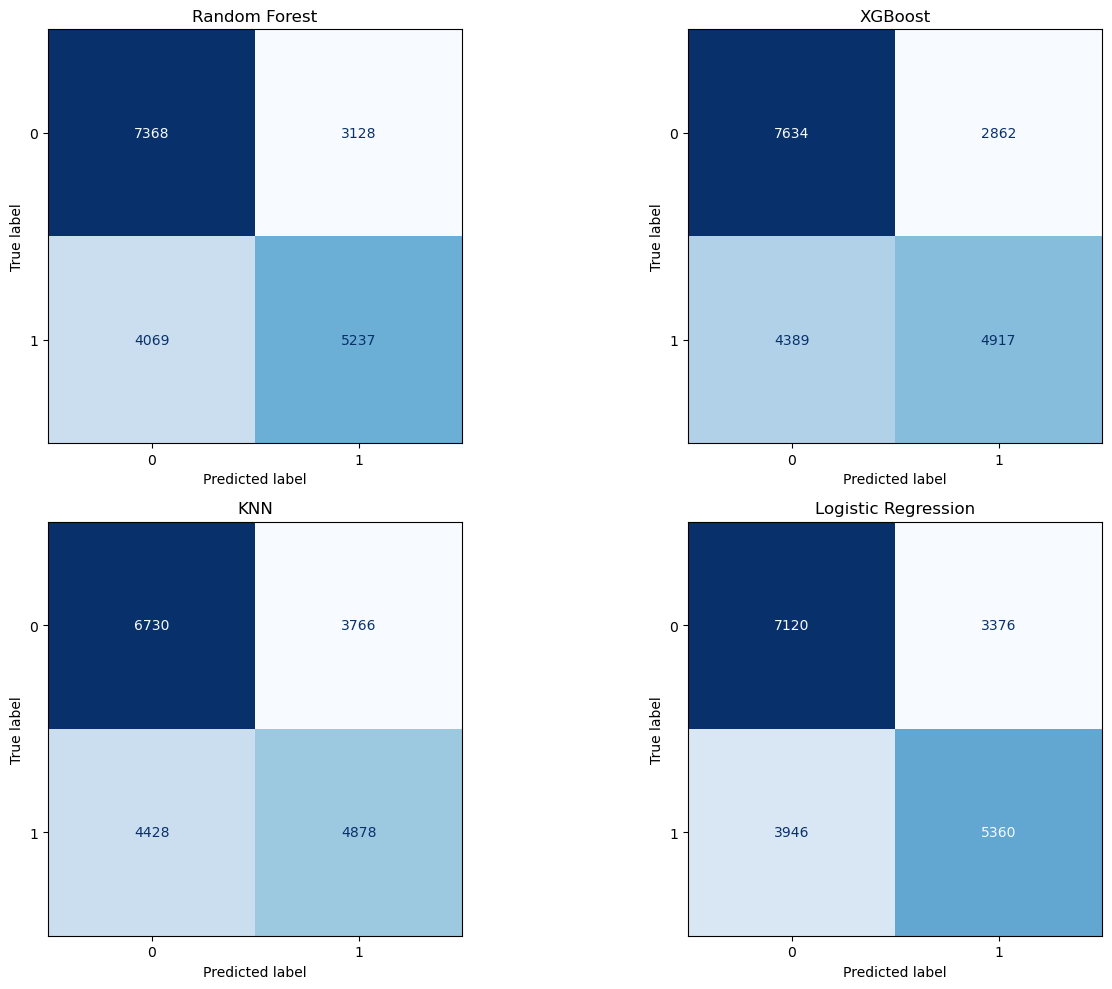

In [84]:
# ==========================================
# 9. Confusion Matrices
# ==========================================

predictions = {
    'Random Forest': y_pred_rf_tuned,
    'XGBoost': y_pred_xgb,
    'KNN': y_pred_knn,
    'Logistic Regression': y_pred_logreg
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):
    cm = confusion_matrix(
        y_test_encoded,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()


## Final Modeling Notes

- The existing **SMOTETomek** step is kept exactly as it was and is used as the balanced training set.
- Random Forest was given a **GridSearchCV** hyperparameter search.
- **XGBoost, KNN, and Logistic Regression** were added with GridSearchCV.
- KNN and Logistic Regression use scaling inside a Pipeline so the scaling is learned only from each training fold.
- The final comparison is based on **test accuracy**, while the classification reports also show precision, recall, and F1-score.
